# COVID Vaccine Data Analyses

- Vaccination status and related clinical metadata were incorporated into the analytical framework to assess cancer patients' responses to COVID19 and Flu vaccines
- This secpmd notebook focuses on the COVID19 vaccine analysis
### Load Libraries 

In [1]:
suppressPackageStartupMessages({
  require(data.table)
  require(ggplot2)
  require(ggpubr)
})

subject_color_map <- c(
  "FH1001" = "#1f77b4", "FH1002" = "#ff7f0e", "FH1003" = "#279e68",
  "FH1004" = "#d62728", "FH1005" = "#aa40fc", "FH1006" = "#8c564b",
  "FH1007" = "#e377c2", "FH1008" = "#b5bd61", "FH1009" = "#17becf",
  "FH1010" = "#aec7e8", "FH1011" = "#ffbb78", "FH1012" = "#98df8a",
  "FH1014" = "#ff9896", "FH1016" = "#c5b0d5", "FH1017" = "#c49c94",
  "FH1018" = "#f7b6d2", "FH1021" = "#dbdb8d"
)

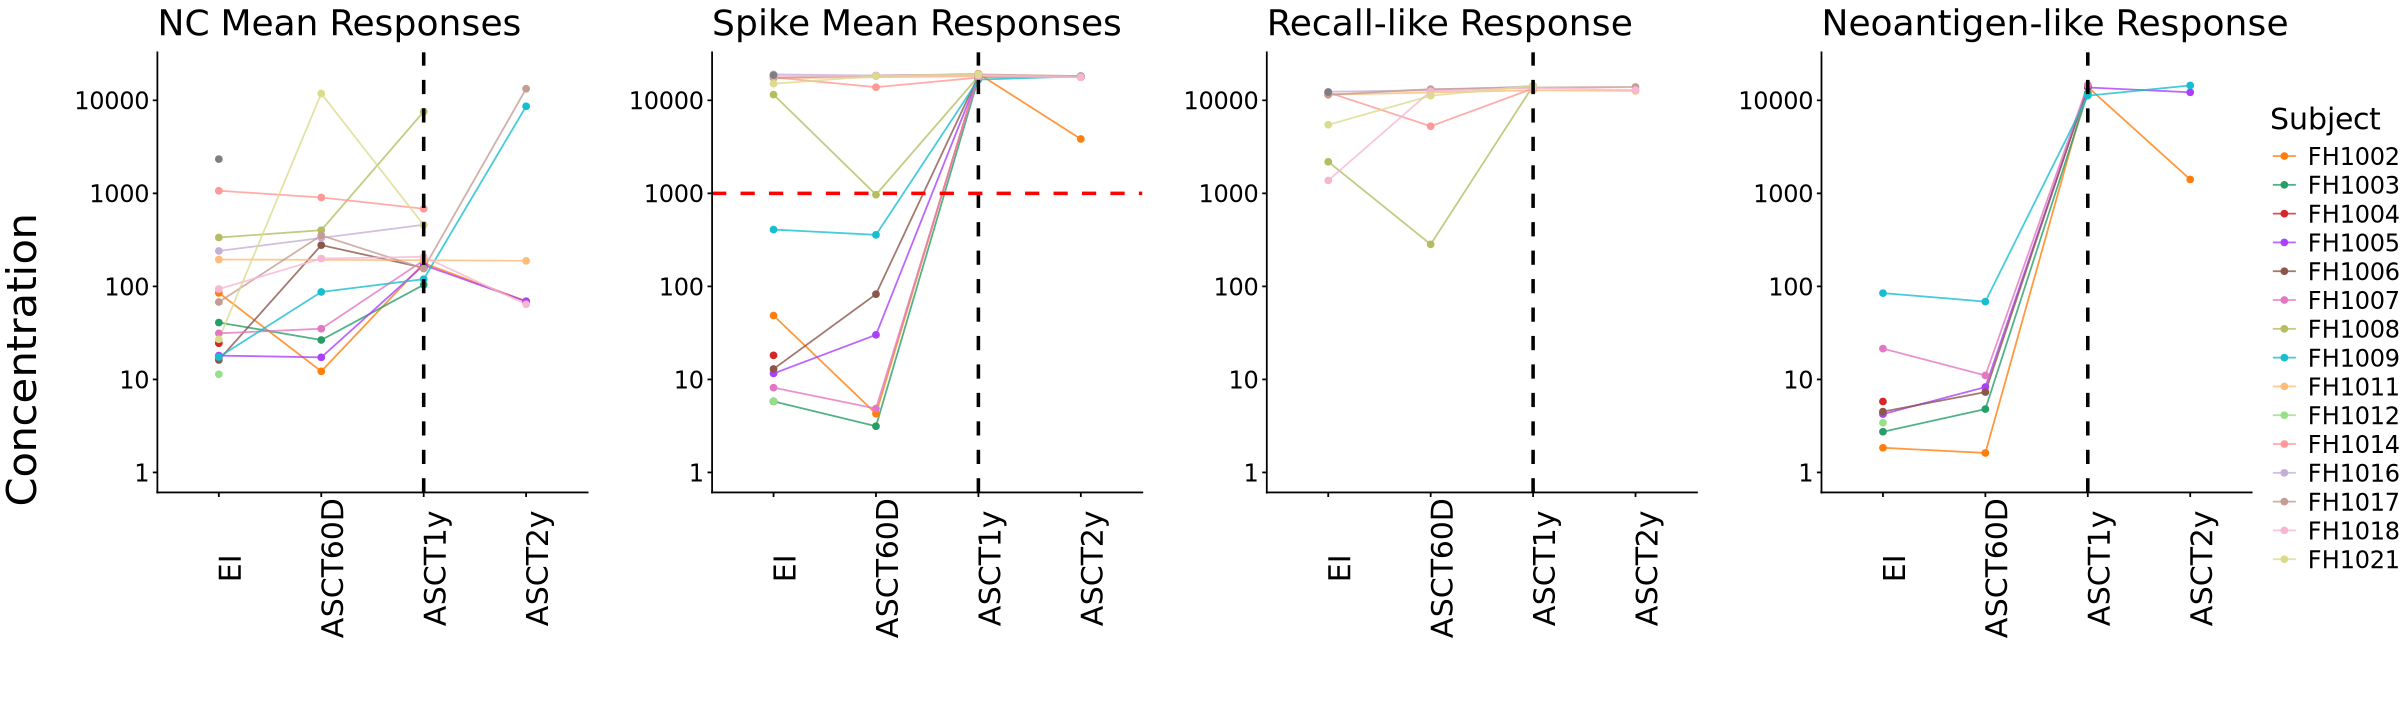

In [2]:
textSize <- 18

tmp <- fread("../../data/figure-inputs/msd/processed_covid_data.csv")

# Recode and reorder visits
visit_levels <- c("EI", "ASCT60D", "ASCT1y", "ASCT2y")
tmp[, Visit := factor(fcase(Visit == "End-Ind", "EI", default = Visit), levels = visit_levels)]

# Define recall responders
recall_subjects <- tmp[variable == "XBB15V2_Mean" & value > 1000 & Visit == "EI", unique(Subject)]

# Base plot helper
base_plot <- function(data, title) {
  ggplot(data, aes(x = Visit, y = value, group = Subject, color = Subject)) +
    geom_line(alpha = 0.8) +
    geom_point() +
    geom_vline(xintercept = "ASCT1y", lty = 2, lwd = 1) +
    scale_y_log10(limits = c(1, 20000)) +
    scale_color_manual(values = subject_color_map) +
    ggtitle(title) +
    xlab("") + ylab("") +
    theme_classic() +
    theme(
      text = element_text(size = textSize),
      axis.text.x = element_text(size = textSize, angle = 90)
    )
}

p_nc     <- base_plot(tmp[variable == "NC_Mean"],    "NC Mean Responses")
p_spike  <- base_plot(tmp[variable == "Spike_Mean"], "Spike Mean Responses") +
              geom_hline(yintercept = 1000, lty = 2, lwd = 1, col = "red")
p_recall <- base_plot(tmp[variable == "XBB15V2_Mean" &  Subject %in% recall_subjects], "Recall-like Response")
p_neo    <- base_plot(tmp[variable == "XBB15V2_Mean" & !Subject %in% recall_subjects], "Neoantigen-like Response")

options(repr.plot.width = 20, repr.plot.height = 6)

mainFig7D <- ggpubr::ggarrange(
  p_nc, p_spike, p_recall, p_neo,
  nrow = 1, common.legend = TRUE, legend = "right"
) %>% annotate_figure(
  left   = text_grob("Concentration", rot = 90, size = 25),
  bottom = text_grob("", size = 25)
)

mainFig7D
ggsave("../../data/figure-outputs/figure-7/fig_7d.pdf", plot = mainFig7D, width = 20, height = 6, dpi = 200, device = cairo_pdf)